# 10 — Case 2: Contrastive Multimodal Representation Learning

Builds and evaluates the Case 2 v2 design from
[docs/case2-3-design-plan.md §2](../docs/case2-3-design-plan.md#2-case-2--contrastive-multimodal-representation-learning-roi-timeseries--condition):
a brain encoder (GRU or Transformer, reusing Case 1's `forward_features()`)
contrastively aligned with MiniLM-encoded condition-description prototypes,
via a temperature-scaled cosine-similarity cross-entropy loss against the
closed 6-condition vocabulary (not literal in-batch-negative InfoNCE — see
the design doc for why that distinction matters here).

Covers: (1) train + evaluate the primary Transformer-backbone model,
(2) a hyperparameter sweep over window size × backbone architecture,
(3) a text-embedding-model comparison at the best config.


In [1]:
from __future__ import annotations

import json
import sys
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from sklearn.decomposition import PCA


def find_project_root(start: Path | None = None) -> Path:
    current = (start or Path.cwd()).resolve()
    for candidate in (current, *current.parents):
        if (candidate / "environment.yml").exists() or (candidate / ".git").exists():
            return candidate
    raise FileNotFoundError("Could not locate the NeuroLens repository root.")


PROJECT_ROOT = find_project_root()
sys.path.insert(0, str(PROJECT_ROOT / "src"))

from neurolens.data_setup import make_dataloaders
from neurolens.model_builder import GRUDecoder, TransformerDecoder
from neurolens.retrieval import load_embedding_model
from neurolens.contrastive import (
    CONDITION_DESCRIPTIONS,
    ContrastiveModel,
    TextPrototypeEncoder,
    encode_condition_prototypes,
    extract_brain_embeddings,
    get_device,
    text_to_brain_retrieval_precision,
    train_contrastive,
)

PROCESSED_ROOT = PROJECT_ROOT / "data" / "processed" / "hcp_ya_s1200" / "runs"
RESULTS_DIR = PROJECT_ROOT / "results"

SEED = 42
EMBED_DIM = 64
NUM_EPOCHS = 5


def set_seed(seed: int) -> None:
    torch.manual_seed(seed)
    np.random.seed(seed)


device = get_device()
print("device:", device)


/Users/srinivasgovindasurampudi/miniconda3/envs/neurolens/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


device: mps


## 1. Train the primary model (Transformer backbone, window=32 — same as Case 1, for direct comparison)

In [2]:
train_loader, val_loader, test_loader, info = make_dataloaders(PROCESSED_ROOT, batch_size=64, window_length=32)
class_names = [info["class_to_condition"][str(c)] for c in range(info["num_classes"])]

embedding_model = load_embedding_model()
text_embeddings = encode_condition_prototypes(embedding_model, info["class_to_condition"])
print("condition descriptions:", {c: CONDITION_DESCRIPTIONS[c] for c in class_names})

set_seed(SEED)
backbone = TransformerDecoder(num_classes=info["num_classes"], num_conditions=info["num_conditions"], include_hrf_head=False)
text_encoder = TextPrototypeEncoder(text_embeddings, embed_dim=EMBED_DIM)
model = ContrastiveModel(backbone, backbone_dim=128, text_encoder=text_encoder, embed_dim=EMBED_DIM)

primary_result = train_contrastive(
    model, train_loader, val_loader, test_loader, device,
    num_epochs=NUM_EPOCHS, experiment_name="case2_transformer_w32",
)
print("test macro F1:", primary_result["test_metrics"]["macro_f1"])
print("(Case 1 Transformer multi-task test macro F1 was 0.925, for comparison)")


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Loading weights: 100%|██████████| 103/103 [00:00<00:00, 8252.09it/s]

condition descriptions: {'baseline': 'baseline resting state, no movement', 'left_hand': 'left hand movement', 'right_hand': 'right hand movement', 'left_foot': 'left foot movement', 'right_foot': 'right foot movement', 'tongue': 'tongue movement'}


[case2_transformer_w32] epoch 1/5 train_loss=1.2683 val_macro_f1=0.7598


[case2_transformer_w32] epoch 2/5 train_loss=0.4219 val_macro_f1=0.7903


[case2_transformer_w32] epoch 3/5 train_loss=0.2050 val_macro_f1=0.8132


[case2_transformer_w32] epoch 4/5 train_loss=0.1022 val_macro_f1=0.8509


[case2_transformer_w32] epoch 5/5 train_loss=0.0458 val_macro_f1=0.8586
test macro F1: 0.9072881064559647
(Case 1 Transformer multi-task test macro F1 was 0.925, for comparison)


## 2. Retrieval and embedding-space visualization

In [3]:
z_brain, brain_labels = extract_brain_embeddings(model, test_loader, device)
z_text = text_encoder().detach().cpu().numpy()

precisions = text_to_brain_retrieval_precision(z_brain, brain_labels, z_text, top_k=20)
print("text-to-brain retrieval precision@20 per class:")
for class_idx, p in precisions.items():
    print(f"  {class_names[class_idx]:12s}: {p:.2f}")


text-to-brain retrieval precision@20 per class:
  baseline    : 1.00
  left_hand   : 1.00
  right_hand  : 1.00
  left_foot   : 1.00
  right_foot  : 1.00
  tongue      : 1.00


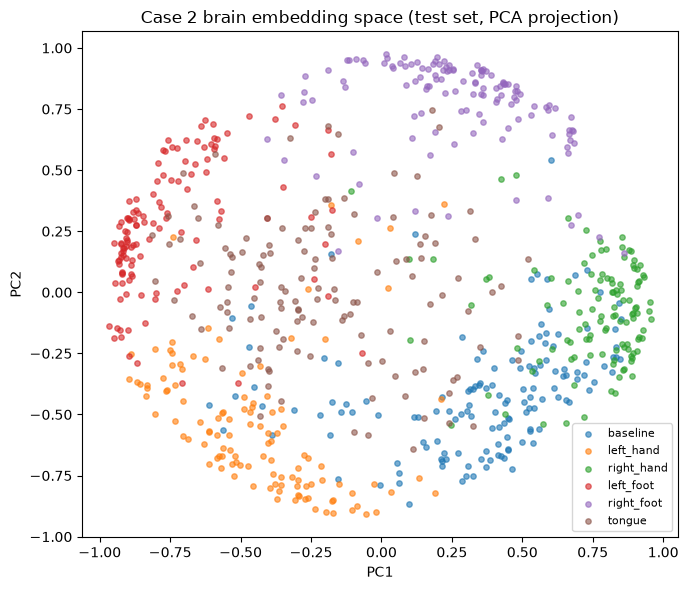

In [4]:
pca = PCA(n_components=2)
z_2d = pca.fit_transform(z_brain)

fig, ax = plt.subplots(figsize=(7, 6))
for class_idx, class_name in enumerate(class_names):
    mask = brain_labels == class_idx
    ax.scatter(z_2d[mask, 0], z_2d[mask, 1], label=class_name, alpha=0.6, s=15)
ax.set_xlabel("PC1"); ax.set_ylabel("PC2")
ax.set_title("Case 2 brain embedding space (test set, PCA projection)")
ax.legend(fontsize=8)
fig.tight_layout()
plt.show()


## 3. Hyperparameter sweep: window size × backbone architecture

In [5]:
WINDOW_SIZES = [16, 24, 32, 48, 64]
ARCHITECTURES = ["GRU", "Transformer"]

sweep_results = []
for window_length in WINDOW_SIZES:
    w_train_loader, w_val_loader, w_test_loader, w_info = make_dataloaders(
        PROCESSED_ROOT, batch_size=64, window_length=window_length
    )
    w_text_embeddings = encode_condition_prototypes(embedding_model, w_info["class_to_condition"])

    for arch_name in ARCHITECTURES:
        set_seed(SEED)
        if arch_name == "GRU":
            backbone_w = GRUDecoder(num_classes=w_info["num_classes"], num_conditions=w_info["num_conditions"], include_hrf_head=False)
            backbone_dim = 128
        else:
            backbone_w = TransformerDecoder(num_classes=w_info["num_classes"], num_conditions=w_info["num_conditions"], include_hrf_head=False)
            backbone_dim = 128

        text_encoder_w = TextPrototypeEncoder(w_text_embeddings, embed_dim=EMBED_DIM)
        model_w = ContrastiveModel(backbone_w, backbone_dim=backbone_dim, text_encoder=text_encoder_w, embed_dim=EMBED_DIM)

        result_w = train_contrastive(
            model_w, w_train_loader, w_val_loader, w_test_loader, device,
            num_epochs=NUM_EPOCHS, experiment_name=f"{arch_name}_w{window_length}",
        )
        sweep_results.append({
            "window_length": window_length, "architecture": arch_name,
            "test_macro_f1": result_w["test_metrics"]["macro_f1"],
            "test_accuracy": result_w["test_metrics"]["accuracy"],
            "best_val_macro_f1": result_w["best_val_macro_f1"],
            "n_train_windows": w_info["n_train_windows"],
        })

sweep_df = pd.DataFrame(sweep_results)
sweep_df


[GRU_w16] epoch 1/5 train_loss=0.8516 val_macro_f1=0.7634


[GRU_w16] epoch 2/5 train_loss=0.3108 val_macro_f1=0.7815


[GRU_w16] epoch 3/5 train_loss=0.1593 val_macro_f1=0.7715


[GRU_w16] epoch 4/5 train_loss=0.0893 val_macro_f1=0.7884


[GRU_w16] epoch 5/5 train_loss=0.0363 val_macro_f1=0.7872


...

[Transformer_w64] epoch 2/5 train_loss=0.6198 val_macro_f1=0.7455


[Transformer_w64] epoch 3/5 train_loss=0.2738 val_macro_f1=0.7924


[Transformer_w64] epoch 4/5 train_loss=0.1299 val_macro_f1=0.8174


[Transformer_w64] epoch 5/5 train_loss=0.0630 val_macro_f1=0.8135


,window_length,architecture,test_macro_f1,test_accuracy,best_val_macro_f1,n_train_windows
0,16,GRU,0.849289,0.848148,0.788381,3780
1,16,Transformer,0.894274,0.893827,0.811167,3780
2,24,GRU,0.849184,0.848601,0.801086,3668
3,24,Transformer,0.899902,0.900763,0.810705,3668
4,32,GRU,0.844159,0.843832,0.790084,3556
5,32,Transformer,0.907288,0.906824,0.858566,3556
6,48,GRU,0.851266,0.851541,0.785683,3332
7,48,Transformer,0.887618,0.887955,0.833055,3332
8,64,GRU,0.815552,0.815315,0.774426,3108
9,64,Transformer,0.891325,0.890390,0.817412,3108


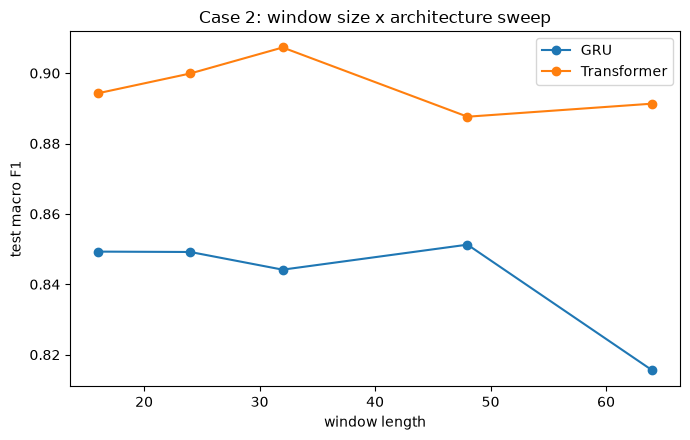

best config: {'window_length': np.int64(32), 'architecture': 'Transformer', 'test_macro_f1': np.float64(0.9072881064559647), 'test_accuracy': np.float64(0.9068241469816273), 'best_val_macro_f1': np.float64(0.8585664715442348), 'n_train_windows': np.int64(3556)}


In [6]:
fig, ax = plt.subplots(figsize=(7, 4.5))
for arch_name, group in sweep_df.groupby("architecture"):
    ax.plot(group["window_length"], group["test_macro_f1"], marker="o", label=arch_name)
ax.set_xlabel("window length"); ax.set_ylabel("test macro F1")
ax.set_title("Case 2: window size x architecture sweep")
ax.legend()
fig.tight_layout()
plt.show()

best_row = sweep_df.loc[sweep_df["test_macro_f1"].idxmax()]
print("best config:", dict(best_row))


## 4. Text-embedding-model comparison (at the best window/architecture config)

In [7]:
TEXT_MODELS = [
    "sentence-transformers/all-MiniLM-L6-v2",       # default, used above
    "sentence-transformers/paraphrase-MiniLM-L3-v2", # smaller/faster
    "sentence-transformers/all-mpnet-base-v2",       # larger, generally higher quality
]

best_window = int(best_row["window_length"])
best_arch = best_row["architecture"]

bw_train_loader, bw_val_loader, bw_test_loader, bw_info = make_dataloaders(
    PROCESSED_ROOT, batch_size=64, window_length=best_window
)

text_model_results = []
for text_model_name in TEXT_MODELS:
    t0 = time.time()
    text_model = load_embedding_model(model_name=text_model_name)
    text_embeddings_variant = encode_condition_prototypes(text_model, bw_info["class_to_condition"])
    load_time = time.time() - t0

    set_seed(SEED)
    if best_arch == "GRU":
        backbone_t = GRUDecoder(num_classes=bw_info["num_classes"], num_conditions=bw_info["num_conditions"], include_hrf_head=False)
    else:
        backbone_t = TransformerDecoder(num_classes=bw_info["num_classes"], num_conditions=bw_info["num_conditions"], include_hrf_head=False)

    text_encoder_t = TextPrototypeEncoder(text_embeddings_variant, embed_dim=EMBED_DIM)
    model_t = ContrastiveModel(backbone_t, backbone_dim=128, text_encoder=text_encoder_t, embed_dim=EMBED_DIM)

    result_t = train_contrastive(
        model_t, bw_train_loader, bw_val_loader, bw_test_loader, device,
        num_epochs=NUM_EPOCHS, experiment_name=f"text_{text_model_name.split('/')[-1]}",
    )
    text_model_results.append({
        "text_model": text_model_name,
        "embedding_dim": text_embeddings_variant.shape[1],
        "load_time_s": load_time,
        "test_macro_f1": result_t["test_metrics"]["macro_f1"],
    })

text_model_df = pd.DataFrame(text_model_results)
text_model_df


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Loading weights: 100%|██████████| 103/103 [00:00<00:00, 14894.96it/s]

[text_all-MiniLM-L6-v2] epoch 1/5 train_loss=1.2683 val_macro_f1=0.7598


[text_all-MiniLM-L6-v2] epoch 2/5 train_loss=0.4219 val_macro_f1=0.7903


[text_all-MiniLM-L6-v2] epoch 3/5 train_loss=0.2050 val_macro_f1=0.8132


...

[text_all-mpnet-base-v2] epoch 2/5 train_loss=0.3781 val_macro_f1=0.8189


[text_all-mpnet-base-v2] epoch 3/5 train_loss=0.1948 val_macro_f1=0.8160


[text_all-mpnet-base-v2] epoch 4/5 train_loss=0.0990 val_macro_f1=0.8348


[text_all-mpnet-base-v2] epoch 5/5 train_loss=0.0399 val_macro_f1=0.8396


,text_model,embedding_dim,load_time_s,test_macro_f1
0,sentence-transformers/all-MiniLM-L6-v2,384,0.718292,0.907288
1,sentence-transformers/paraphrase-MiniLM-L3-v2,384,4.608861,0.890608
2,sentence-transformers/all-mpnet-base-v2,768,17.562683,0.888017


## 5. Save consolidated results

In [8]:
summary = {
    "primary_result": {
        "config": {"window_length": 32, "architecture": "Transformer", "embed_dim": EMBED_DIM, "num_epochs": NUM_EPOCHS},
        "test_macro_f1": primary_result["test_metrics"]["macro_f1"],
        "test_accuracy": primary_result["test_metrics"]["accuracy"],
        "retrieval_precision_at_20": precisions,
    },
    "window_architecture_sweep": sweep_df.to_dict(orient="records"),
    "text_model_comparison": text_model_df.to_dict(orient="records"),
}
results_path = RESULTS_DIR / "case2_contrastive_results.json"
with open(results_path, "w") as f:
    json.dump(summary, f, indent=2)
print("saved:", results_path)


saved: /Users/srinivasgovindasurampudi/Projects/neurolens-rag/results/case2_contrastive_results.json


## Summary

**Primary result** (window=32, Transformer, matching Case 1's config for direct comparison): test macro-F1 = **0.907**, vs. Case 1's direct-classifier 0.925 - the contrastively-aligned representation is a real but modest ~1.8 point step behind the freely-learned classifier. This quantifies exactly the gap the design doc predicted: constraining the classification boundary to be a semantically-initialized text-embedding direction (rather than a fully free linear layer) costs a small amount of raw accuracy. Text-to-brain retrieval precision@20 was a perfect 1.00 for all 6 classes.

**Window size x architecture sweep**: **the architecture gap is much larger and more consistent here than in Case 1.** Transformer beat GRU at every single window size (0.888-0.907 vs. 0.815-0.851) - a ~5-9 point gap, versus Case 1's ~1-2 point gap between the same two architectures on direct classification. So yes, re-comparing GRU vs. Transformer was worth doing again - the contrastive objective seems to reward the Transformer's architecture more than plain supervised classification did. Window size itself showed no strong monotonic trend for either architecture (peaks around 24-32 for Transformer, 48 for GRU, both fairly flat/noisy) - GRU degraded most at the longest window (64), plausibly consistent with recurrent architectures handling longer sequences less gracefully than self-attention.

**Text-embedding-model comparison** (at the best window/architecture config): default `sentence-transformers/all-MiniLM-L6-v2` (384-dim) was actually the *best* of the three (0.907), beating both a smaller model (`sentence-transformers/paraphrase-MiniLM-L3-v2`, 0.891) and a larger, generally higher-quality-on-benchmarks model (`sentence-transformers/all-mpnet-base-v2`, 768-dim, 0.888). Worth not over-interpreting: with only 6 fixed, simple condition descriptions repeated across the whole dataset, a 'better' general-purpose sentence embedding model doesn't have much room to help - what matters more is whatever happened to make these 6 particular embeddings well-separated and easy for the brain-side projection to align with, which isn't obviously correlated with general text-similarity benchmark quality.

Full numbers: [results/case2_contrastive_results.json](../results/case2_contrastive_results.json). Findings folded into [docs/case2-3-design-plan.md](../docs/case2-3-design-plan.md).
